In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# load dataset
df = pd.read_csv("../data/raw/heart.csv")

# rename label
df = df.rename(columns={"num":"target"})

# missing value
df = df.fillna(df.median(numeric_only=True))

# convert target to binary
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

# encode categorical
df = pd.get_dummies(df, drop_first=True)

# split feature
X = df.drop("target", axis=1)

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

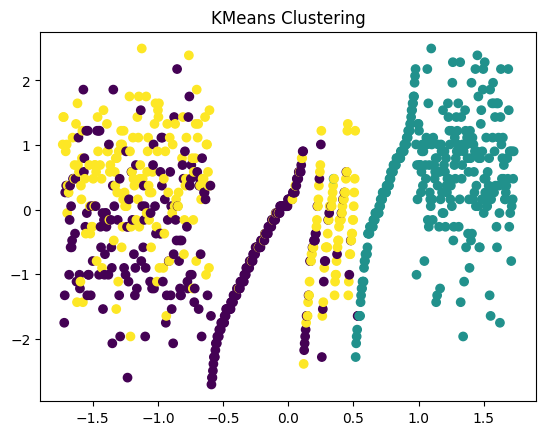

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.title("KMeans Clustering")
plt.show()